<a href="https://colab.research.google.com/github/duane-edgington/PAM_marine_mammels/blob/main/CreateSpectrogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ![alt text](https://www.mbari.org/wp-content/uploads/2014/11/logo-mbari-3b.png "MBARI")

  <div align="left">Copyright (c) 2022, MBARI</div>
    
  * Distributed under the terms of the GPL License
  * Maintainer: yzhang@mbari.org
  * Authors: Yanwu Zhang yzhang@mbari.org, Paul McGill mcgill@mbari.org, Danelle Cline (dcline@mbari.org), John Ryan ryjo@mbari.org

## Creating spectrogram of MARS sound recordings

An extensive (6+ years and growing) archive of sound recordings from a deep-sea location [along the eastern margin of the North Pacific Ocean](https://www.mbari.org/at-sea/cabled-observatory/) has been made available through AWS Open data.  Temporal coverage of the recording archive has been 95% since project inception in July 2015.  The original recordings have a sample rate of 256 kHz. Many research topics can be effectively studied using data with a lower sample rate, and this Open Data project includes daily files decimated to 2 kHz and 16 kHz.  The purpose of this notebook is to illustrate a method of optimizing decimation processing, which is applicable to any desired sample rate. The demonstration uses Python, but the algorithms can be implemented in other languages.

This method enables design of the optimal windowed-sinc anti-aliasing low-pass filter (using a certain window) that meets the desired passband and stopband requirements based on signal retention and exclusion needs. The best combination of the sinc function’s cutoff frequency and the main-lobe bandwidth of the window function generates the shortest qualifying filter.

If you use this data set, please **[cite our project](https://ieeexplore.ieee.org/document/7761363).**


## Data Overview
The full-resolution audio data are in [WAV](https://en.wikipedia.org/wiki/WAV) format in s3 buckets named <b>pacific-sound-256khz-yyyy</b>, where yyyy is 2015 or later.  Buckets are stored as objects, so the data aren't physically stored in folders or directories as you may be familiar with, but you can think of it conceptually as follows:

```
pacific-sound-256khz-2021
      |
      individual 10-minute files
```


## Install required dependencies

First, let's install the required software dependencies.

If you are using this notebook in a cloud environment, select a Python3 compatible kernel and run this next section.  This only needs to be done once for the duration of this notebook.

If you are working on local computer, you can skip this next cell. Change your kernel to *pacific-sound-notebooks*, which you installed according to the instructions in the [README](https://github.com/mbari-org/pacific-sound-notebooks/) - this has all the dependencies that are needed.

In [1]:
!pip install -q boto3 --quiet
!pip install -q soundfile --quiet
!pip install -q scipy --quiet
!pip install -q numpy --quiet
!pip install -q matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 4.7 MB/s eta 0:00:00


### Import all packages

In [2]:
import boto3
from botocore import UNSIGNED
from botocore.client import Config
from six.moves.urllib.request import urlopen
import io
import math
import scipy
from scipy import signal, interpolate
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

In [3]:
# connect google drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True) # This will prompt for authorization.

Mounted at /content/drive


## List the contents of a monthly directory

In [4]:
s3 = boto3.client('s3',
    aws_access_key_id='',
    aws_secret_access_key='',
    config=Config(signature_version=UNSIGNED))

In [5]:
bucket = 'pacific-sound-256khz-2018'

for i, obj in enumerate(s3.list_objects_v2(Bucket=bucket)['Contents']):
  print(obj['Key'])
  if i > 20:
      break

01/MARS_20180101_000406.wav
01/MARS_20180101_001406.wav
01/MARS_20180101_002406.wav
01/MARS_20180101_003406.wav
01/MARS_20180101_004406.wav
01/MARS_20180101_005406.wav
01/MARS_20180101_010406.wav
01/MARS_20180101_011406.wav
01/MARS_20180101_012406.wav
01/MARS_20180101_013406.wav
01/MARS_20180101_014406.wav
01/MARS_20180101_015406.wav
01/MARS_20180101_020406.wav
01/MARS_20180101_021406.wav
01/MARS_20180101_022406.wav
01/MARS_20180101_023406.wav
01/MARS_20180101_024406.wav
01/MARS_20180101_025406.wav
01/MARS_20180101_030406.wav
01/MARS_20180101_031406.wav
01/MARS_20180101_032406.wav
01/MARS_20180101_033406.wav


## Read metadata from a file

In [6]:
bucket = 'pacific-sound-256khz-2018'
filename = '04/MARS_20180413_075913.wav'
url = f'https://{bucket}.s3.amazonaws.com/{filename}'
print(f'Reading metadata from {url}')
sf.info(io.BytesIO(urlopen(url).read(1000)), verbose=True)

Reading metadata from https://pacific-sound-256khz-2018.s3.amazonaws.com/04/MARS_20180413_075913.wav


samplerate: 256000 Hz
channels: 1
duration: 214 samples
format: WAV (Microsoft) [WAV]
subtype: Signed 24 bit PCM [PCM_24]
endian: FILE
sections: 1
frames: 214
extra_info: """
    Length : 1000
    RIFF : 460800348 (should be 992)
    WAVE
    LIST : 304
      INFO
        IART : icListen HF #1689
        IPRD : RB9-ETH R4
        ICRD : 2018-04-13T00:59:13-07
        ISFT : Lucy V4.3.0
        INAM : MARS_20180413_075913.wav
        ICMT : 3.000000 V pk, -177 dBV re 1uPa, 41.8 % RH,  5.8 deg C, 8388608 = Max Count
    fmt  : 16
      Format        : 0x1 => WAVE_FORMAT_PCM
      Channels      : 1
      Sample Rate   : 256000
      Block Align   : 3
      Bit Width     : 24
      Bytes/sec     : 768000
    data : 460800000 (should be 644)
    End
    """

## Read data from a file

In [7]:
## read from a file
#!ls /content/drive/MyDrive/pacific-sound/sox-save_24kHz.wav
#!ls /content/drive/MyDrive/orca/MARS_20180413_075913_24kHz.wav
#!ls /content/drive/MyDrive/orca/24k_decimate_audio.wav
#!ls /content/drive/MyDrive/pacific-sound/24kHz_MARS_20180413_075913.wav
!ls /content/drive/MyDrive/mathmatica/MARS_20180413_075913_24k.wav
#x, sample_rate = sf.read('/content/drive/MyDrive/pacific-sound/sox-save_24kHz.wav')
x, sample_rate = sf.read('/content/drive/MyDrive/mathmatica/MARS_20180413_075913_24k.wav')
#x, sample_rate = sf.read('/content/drive/MyDrive/pacific-sound/24kHz_MARS_20180413_075913.wav')
#x, sample_rate = sf.read('/content/drive/MyDrive/orca/24k_decimate_audio.wav')
#x, sample_rate = sf.read('/content/drive/MyDrive/pacific-sound/claude_24kHz_MARS_20180413_075913.wav')
## write in a difference format
#sf.write('new_file.flac', x, sample_rate)

/content/drive/MyDrive/mathmatica/MARS_20180413_075913_24k.wav


## Read data from a url

In [8]:
## read from a url
#print(f'Reading data from {url}')
#x, sample_rate = sf.read(io.BytesIO(urlopen(url).read()),dtype='float32')

## Produce a spectrogram

### Calibrated Spectrum Levels

### Calibration metadata
Frequency-dependent hydrophone sensitivity data are defined in the following files, one for each deployment:
*   https://bitbucket.org/mbari/pacific-sound/src/master/MBARI_MARS_Hydrophone_Deployment01.json
*   https://bitbucket.org/mbari/pacific-sound/src/master/MBARI_MARS_Hydrophone_Deployment02.json

### Compute spectrogram




In [9]:
# convert scaled voltage to volts
v = x*3
nsec = (v.size)/sample_rate # number of seconds in vector
spa = 1  # seconds per average
nseg = int(nsec/spa)
print(f'{nseg} segments of length {spa} seconds in {nsec} seconds of audio')

600 segments of length 1 seconds in 600.0 seconds of audio


In [10]:
lenfft_input = 2**int(np.ceil(np.log2(sample_rate)))
print(lenfft_input)
#
# initialize empty LTSA
nfreq = int(lenfft_input/2+1)
sg_input = np.empty((nfreq, nseg), float)
sg_input.shape

32768


(16385, 600)

In [11]:
sample_rate = 24000
print(f'sample rate {sample_rate}')

sample rate 24000


In [12]:
# get window
w_input = scipy.signal.get_window('blackman',sample_rate)
window_correction = np.mean(np.square(w_input))
#
numDataPoints_input = int(sample_rate*spa)
#
Ind_keep = np.arange(0, int(lenfft_input/2)+1)
f_input = (Ind_keep/lenfft_input) * sample_rate
#
# Calculate spectrogram
for x in range(0,nseg):
  cstart = x*spa*sample_rate
  cend = (x+1)*spa*sample_rate
#  f,psd = scipy.signal.welch(v[cstart:cend], fs=sample_rate, window=w_input, nfft=sample_rate)
  psd_input = np.square(np.absolute(np.fft.fft(np.multiply(v[cstart:cend],w_input), n=lenfft_input)))/(numDataPoints_input*window_correction)/sample_rate
  psd_input_log10 = 10*np.log10(psd_input[Ind_keep])
  sg_input[:,x] = psd_input_log10
  if (x == 0):
    psd_input_check = psd_input
    print("Comparing power of the input signal computed in the time domain versus that computed in the frequency domain:")
    print(np.mean(np.square(v[cstart:cend])))
    print(sum(psd_input_check)*(sample_rate/lenfft_input))

Comparing power of the input signal computed in the time domain versus that computed in the frequency domain:
0.00011849290737882257
0.00011847378536661778


### Apply calibration
Frequency-dependent hydrophone sensitivity data are reported in the json files identified above.  This example file is from the second hydrophone deployment, for which the calibration data are manually entered below.  Note that the lowest measured value, at 250 Hz, is assumed to cover lower frequencies and repeated as a value at 0 Hz to allow interpolation to the spectrogram output frequencies across the full frequency range.



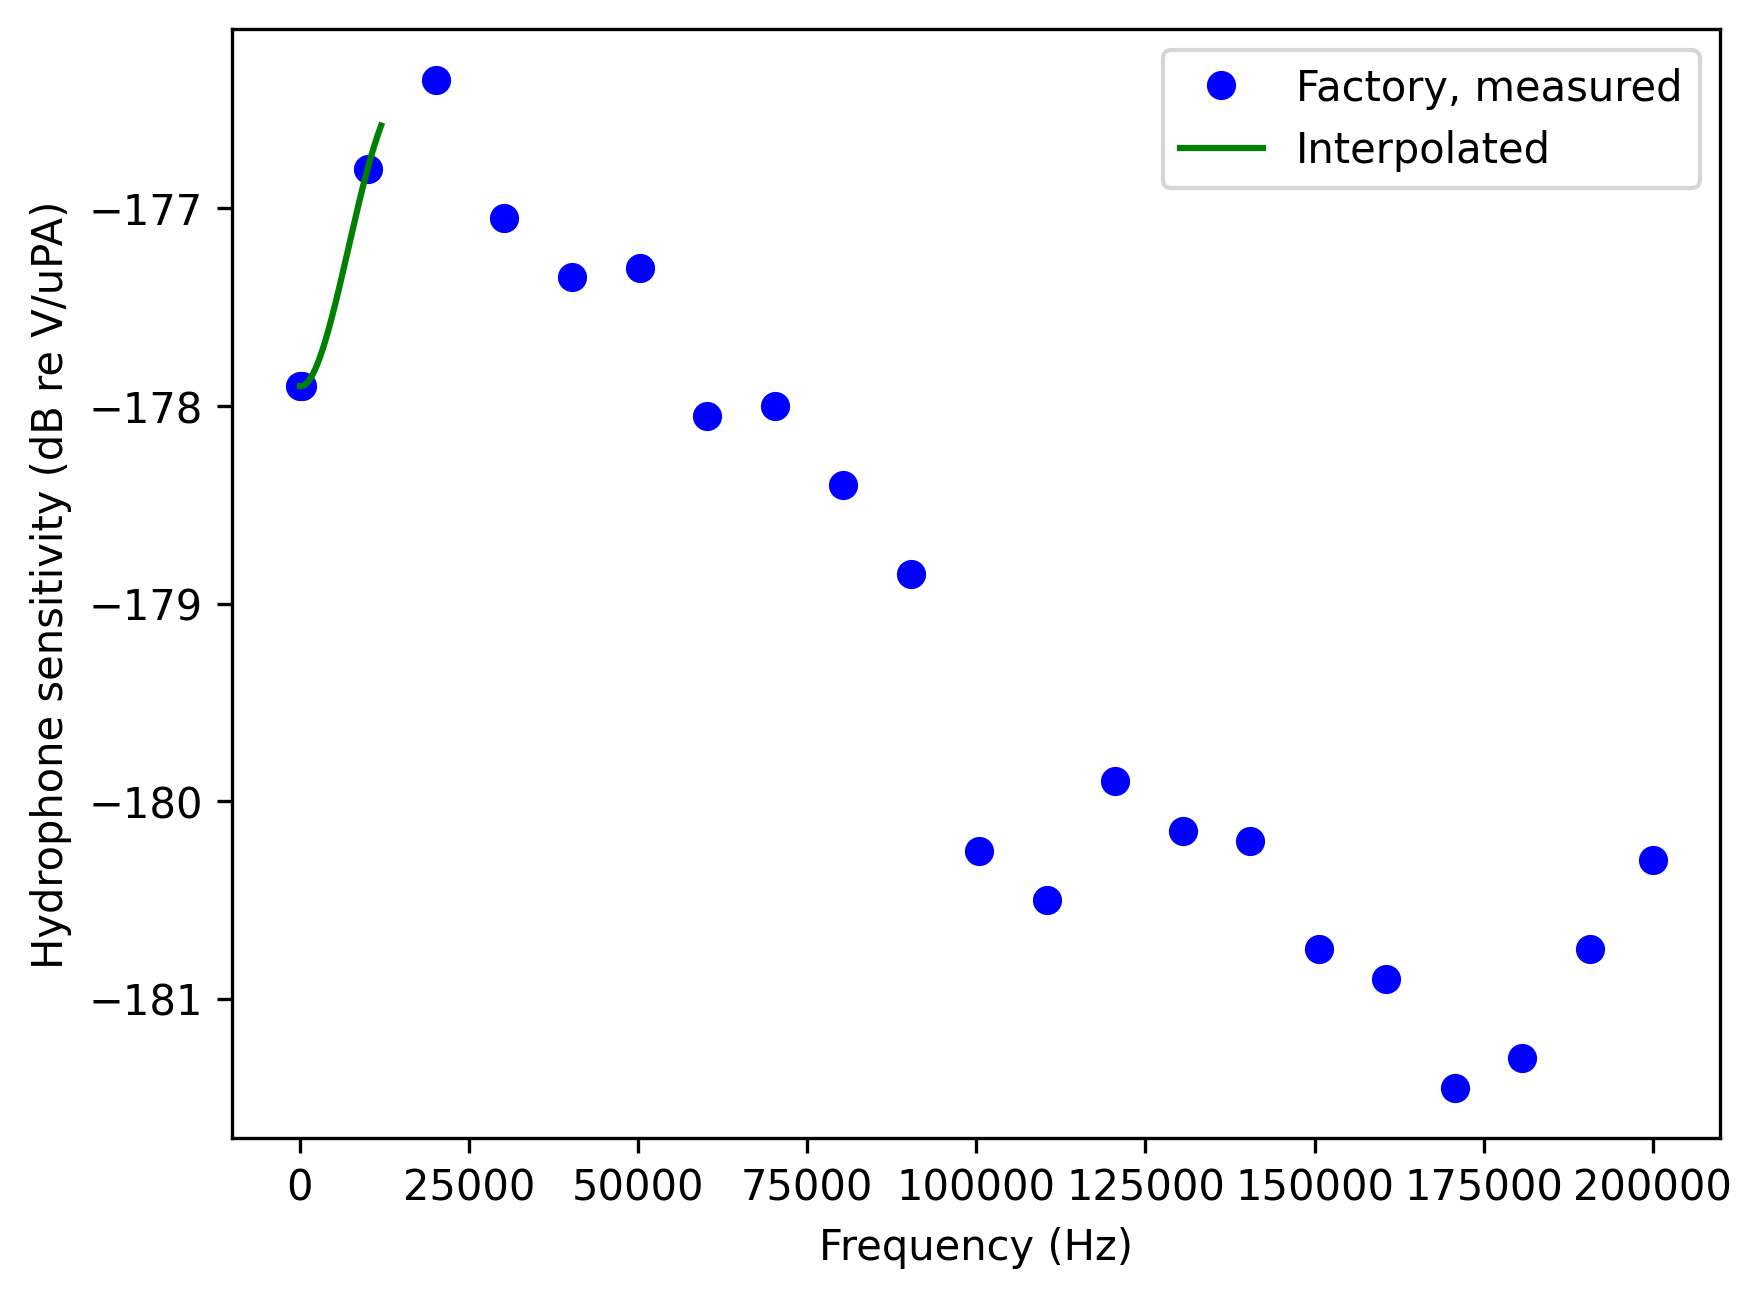

In [13]:
# define hydrophone calibration data
calfreq = [0,250,10000,20100,30100,40200,50200,60200,70300,80300,90400,100400,110400,120500,130500,140500,150600,160600,170700,180700,190700,200000]
calsens = [-177.90,-177.90,-176.80,-176.35,-177.05,-177.35,-177.30,-178.05,-178.00,-178.40,-178.85,-180.25,-180.50,-179.90,-180.15,-180.20,-180.75,-180.90,-181.45,-181.30,-180.75,-180.30]

# interpolate to the frequency resolution of the spectrogram
tck = interpolate.splrep(calfreq, calsens, s=0)
isens = interpolate.splev(f_input, tck, der=0)
plt.figure(dpi=300)
im = plt.plot(calfreq,calsens,'bo',f_input,isens,'g')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Hydrophone sensitivity (dB re V/uPA)')
plt.legend(['Factory, measured', 'Interpolated'])


In [14]:
# replicate interpolated sensitivity
isensg = np.transpose(np.tile(isens,[nseg,1]))
isensg.shape

(16385, 600)

In [15]:
sg_input.shape

(16385, 600)

### Plot the calibrated spectrogram

Text(0.5, 1.0, 'Calibrated spectrum levels (dB) of the 24000 Hz sample-rate input data')

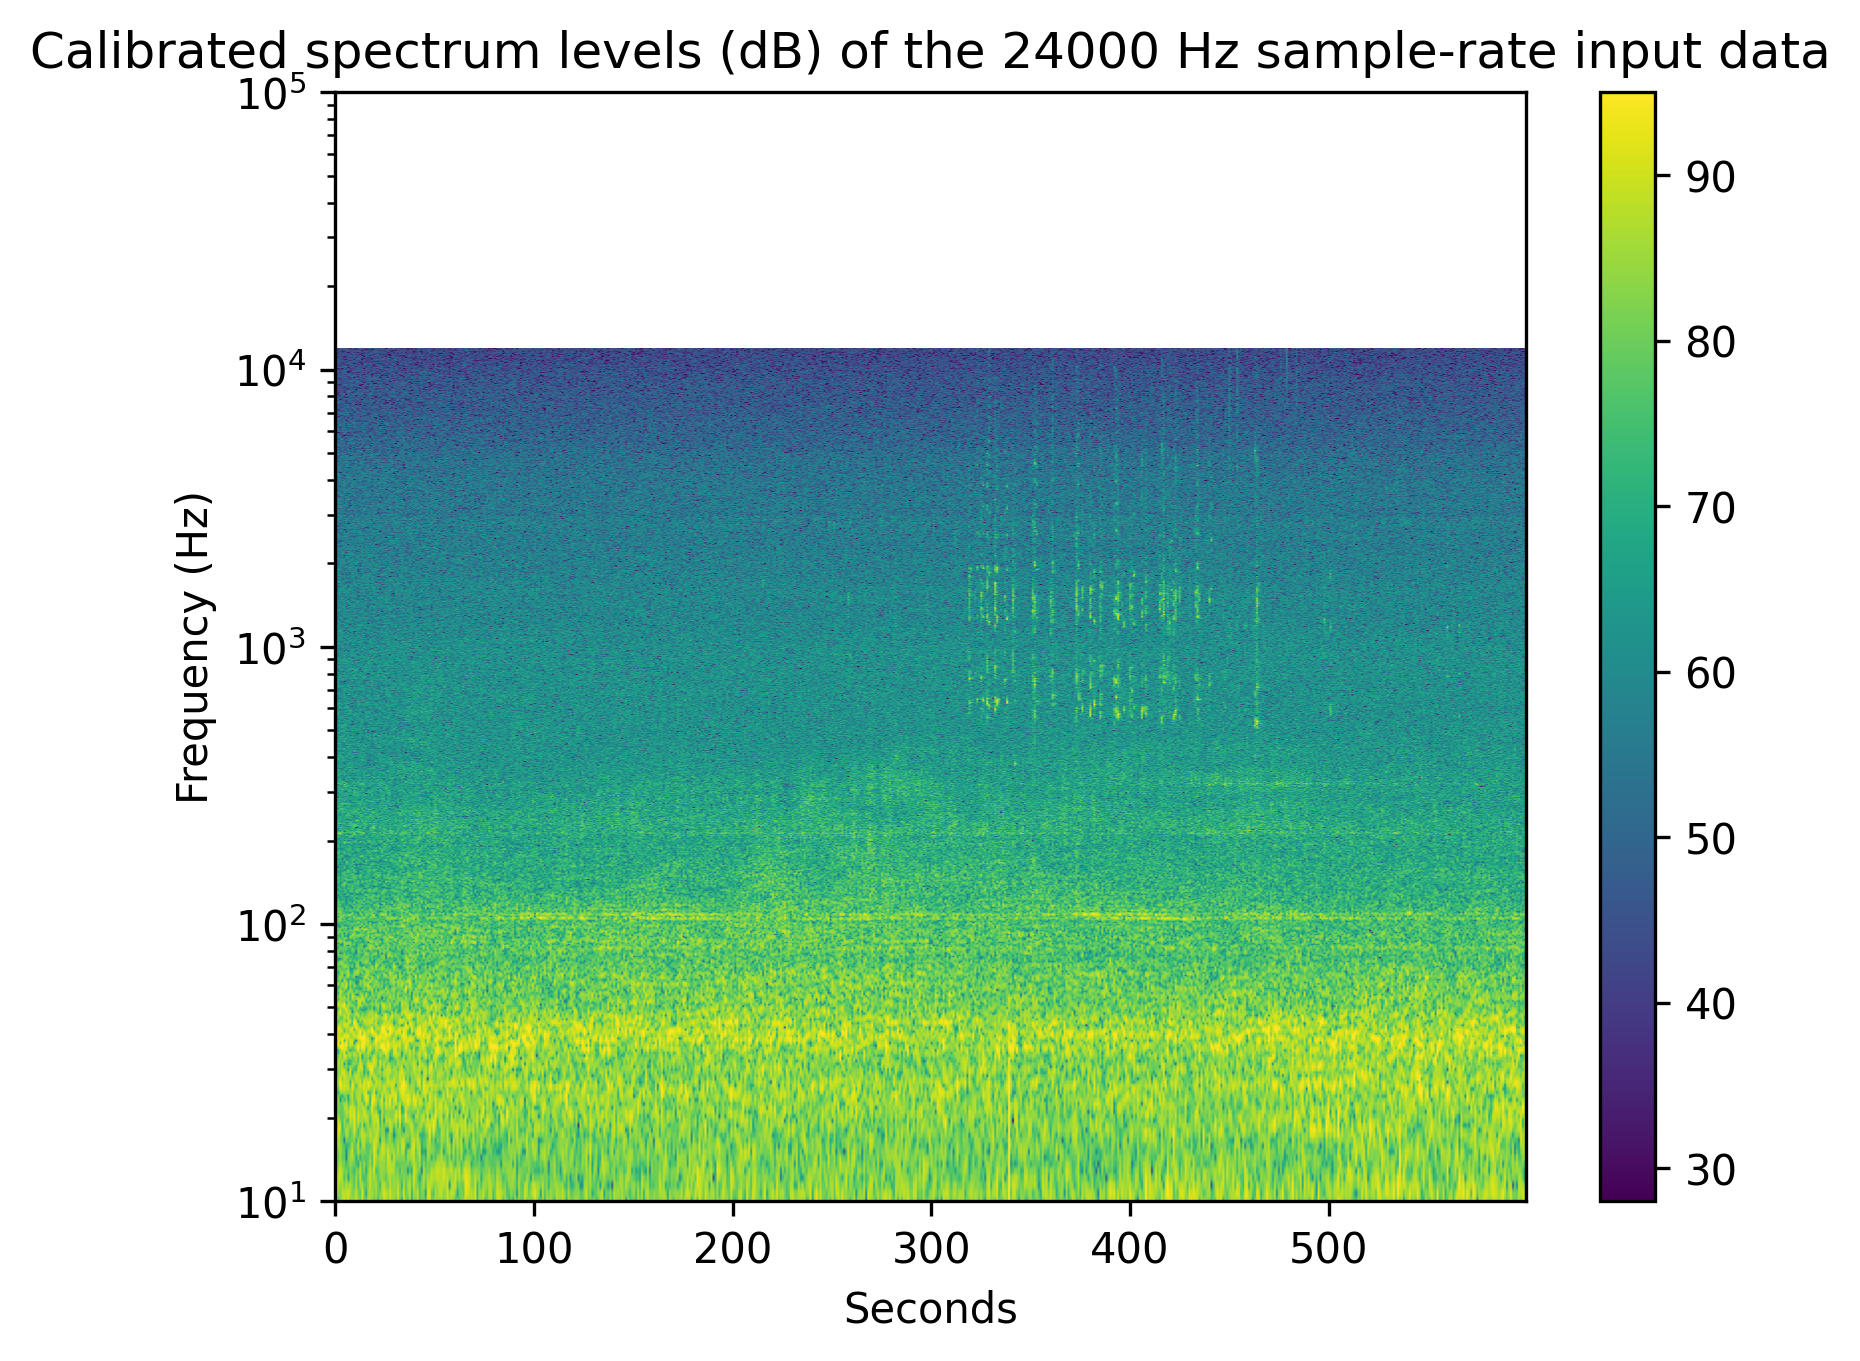

In [16]:
plt.figure(dpi=300)
# plot calibrated
Extent = [0, nseg-1, 0.0, sample_rate/2.0]
im = plt.imshow(sg_input-isensg, extent=Extent, aspect='auto',origin='lower',vmin=28,vmax=95)
#plot uncalibrated
#im = plt.imshow(sg_input,aspect='auto',origin='lower',vmin=28,vmax=95)
plt.yscale('log')
plt.ylim(10,100000)
plt.colorbar(im)
plt.xlabel('Seconds')
plt.ylabel('Frequency (Hz)')
plt.title(f'Calibrated spectrum levels (dB) of the {sample_rate} Hz sample-rate input data')